In [1]:
%pip install -U scikit-learn


You should consider upgrading via the 'c:\Users\User\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\User\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [3]:
import logging
import numpy
import numpy as np
import pandas as pd
from math import *
from datetime import datetime
from operator import itemgetter
from zipfile import ZipFile
from io import BytesIO
import pickle
from urllib.request import urlopen

from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from numpy import inf
from scipy.stats import kurtosis, skew

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import average_precision_score
from sklearn.metrics import mean_squared_error



import warnings
warnings.filterwarnings('ignore')

from functions import *
from fair_func import *

C:\Users\User\AppData\Local\Temp\ipykernel_18704\1146656665.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
from pandas.api.types import CategoricalDtype

In [5]:
%pip install openpyxl


You should consider upgrading via the 'c:\Users\User\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [6]:
encoded_data = pd.read_csv('E:\Jio_Institute\Responsible_AI\ibm_hr_data_encoded_DP1.csv')

In [7]:
encoded_data.shape

(1470, 35)

In [8]:
encoded_data.head().T

,0,1,2,3,4
Age,41.000000,49.000000,37.000000,33.000000,27.000000
Attrition,1.000000,0.000000,1.000000,0.000000,0.000000
BusinessTravel,2.000000,1.000000,2.000000,1.000000,2.000000
DailyRate,1102.000000,279.000000,1373.000000,1392.000000,591.000000
Department,2.000000,1.000000,1.000000,1.000000,1.000000
DistanceFromHome,1.000000,8.000000,2.000000,3.000000,2.000000
Education,2.000000,1.000000,2.000000,4.000000,1.000000
EducationField,1.000000,1.000000,4.000000,1.000000,3.000000
EmployeeCount,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1.000000,2.000000,4.000000,5.000000,7.000000


In [9]:
#0 if favourable [false, default = false]
#1 if unfavourable [true, default = True]
fav=0
unfav=int(not fav)

In [10]:
encoded_data.head().T

,0,1,2,3,4
Age,41.000000,49.000000,37.000000,33.000000,27.000000
Attrition,1.000000,0.000000,1.000000,0.000000,0.000000
BusinessTravel,2.000000,1.000000,2.000000,1.000000,2.000000
DailyRate,1102.000000,279.000000,1373.000000,1392.000000,591.000000
Department,2.000000,1.000000,1.000000,1.000000,1.000000
DistanceFromHome,1.000000,8.000000,2.000000,3.000000,2.000000
Education,2.000000,1.000000,2.000000,4.000000,1.000000
EducationField,1.000000,1.000000,4.000000,1.000000,3.000000
EmployeeCount,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1.000000,2.000000,4.000000,5.000000,7.000000


In [11]:

label_names=['Attrition']

protected_attribute_names = ['Gender','NumCompaniesWorked', 'JobRole','BusinessTravel',
                              'OverTime', 'MaritalStatus','Department','StockOptionLevel']

In [12]:
privileged_groups = [{'Gender': 0},  {'NumCompaniesWorked': 0},
                     {'JobRole': 0},{'BusinessTravel':0}, {'OverTime': 0},{'MaritalStatus': 0},{'Department': 0},{'StockOptionLevel': 0}
                     ]

unprivileged_groups = [{'Gender': 1}, {'NumCompaniesWorked': 1},
                       {'JobRole': 1}, {'BusinessTravel':1},{'OverTime': 1},{'MaritalStatus': 1},{'Department': 1},{'StockOptionLevel': 1}
                    ]
input_dataframe = encoded_data.copy()
LABEL_NAMES = label_names
PROTECTED_ATTRIBUTE_NAMES = protected_attribute_names
PRIVILEGED_GROUPS = privileged_groups
UNPRIVILEGED_GROUP = unprivileged_groups

SP = []
DI = []
Protected = []

for group in range(len(protected_attribute_names)):
    protected_attribute_name = list(privileged_groups[group].keys())[0]
    privileged_group_protected_attribute_value = PRIVILEGED_GROUPS[group][protected_attribute_name]
    unprivileged_group_protected_attribute_value = UNPRIVILEGED_GROUP[group][protected_attribute_name]

    print(protected_attribute_name, privileged_group_protected_attribute_value, unprivileged_group_protected_attribute_value)

    
    stat_parity, disprate_impact = stat_parity_test(encoded_data, protected_attribute_name, 'Attrition',fav,
                                                    privileged_group_protected_attribute_value,
                                                    unprivileged_group_protected_attribute_value)

    if disprate_impact != 0 and unprivileged_group_protected_attribute_value != 0:
        SP.append(stat_parity)
        DI.append(disprate_impact)
        Protected.append(protected_attribute_name)

    print("")

Gender 0 1
Statistical Parity Difference -0.022108843537414935
Disparate Impact 0.9740518962075849

NumCompaniesWorked 0 1
Statistical Parity Difference -0.07134853902588734
Disparate Impact 0.9192203322522999

JobRole 0 1
Statistical Parity Difference -0.16206694069289485
Disparate Impact 0.8259773013871375

BusinessTravel 0 1
Statistical Parity Difference -0.16909747292418775
Disparate Impact 0.8161983989954481

OverTime 0 1
Statistical Parity Difference -0.20092413516274998
Disparate Impact 0.7756630948500651

MaritalStatus 0 1
Statistical Parity Difference -0.023896833294709485
Disparate Impact 0.9734208690905782

Department 0 1
Statistical Parity Difference 0.05207868787473369
Disparate Impact 1.0643324967864358

StockOptionLevel 0 1
Statistical Parity Difference 0.1500973207543156
Disparate Impact 1.198556413828036



In [13]:
SP, DI, Protected
d = pd.DataFrame({'Protected_feature':Protected,'Statistical_Parity':SP,'Disparate_Impact':DI})
d['DI_normal']=d["Disparate_Impact"].apply(lambda x: 1/x if x < 1 else x)
d['SP_normal']=d["Statistical_Parity"].apply(lambda x: abs(x) if x < 0 else x)
#d

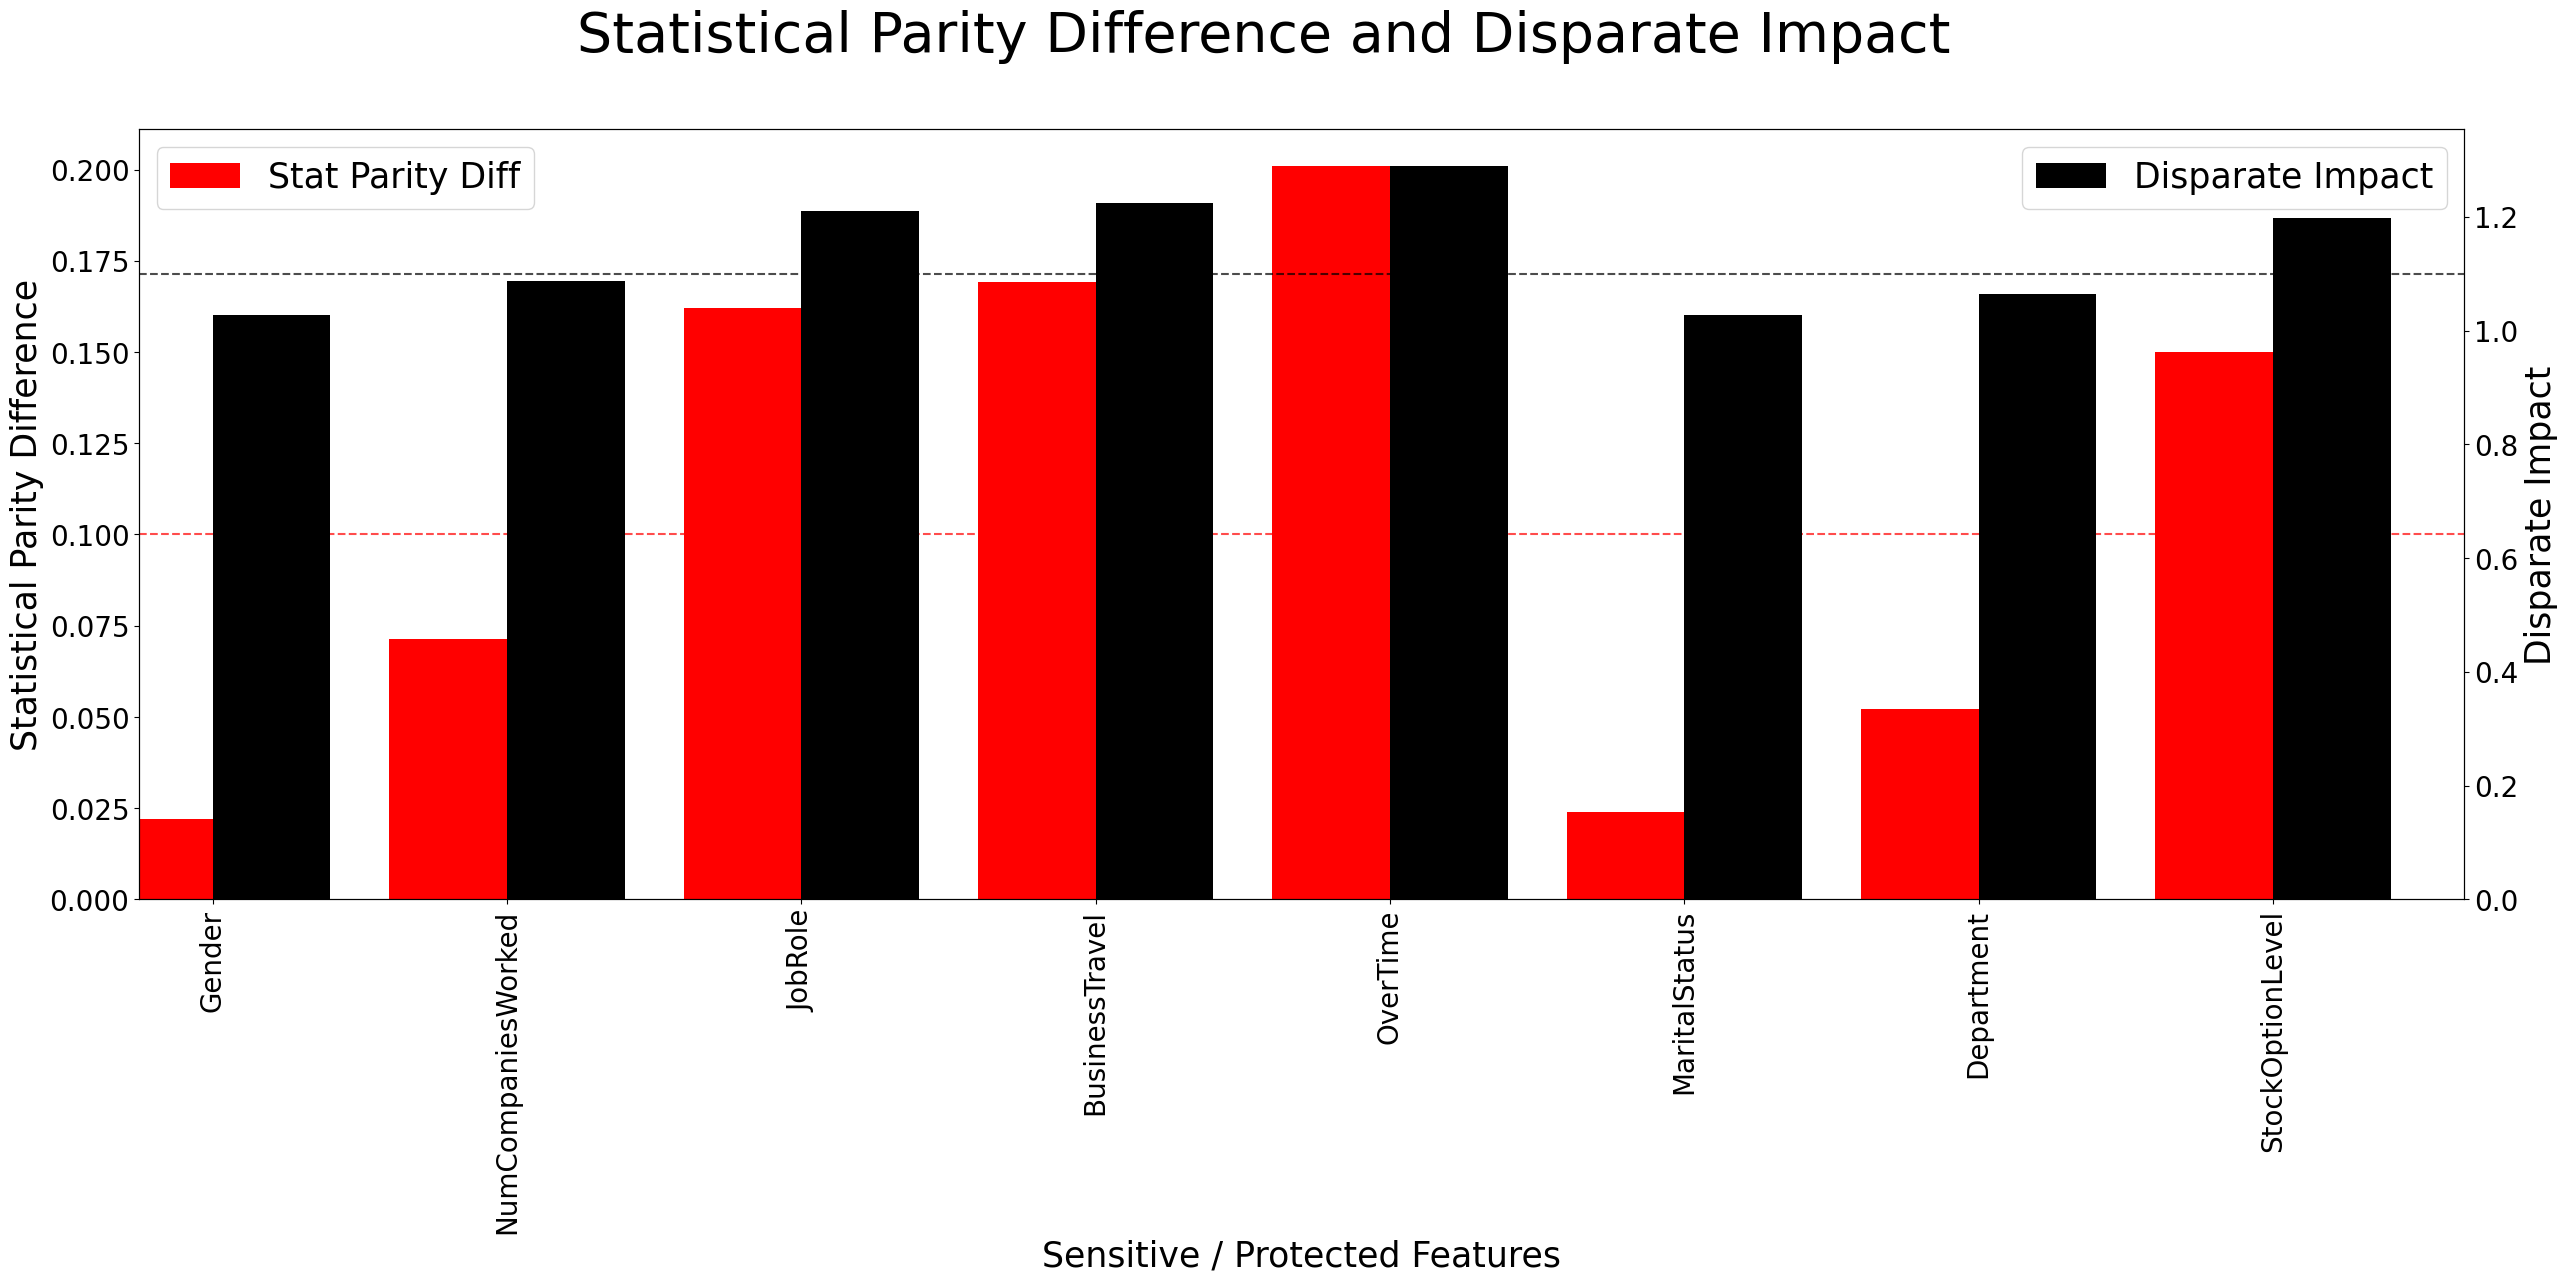

In [14]:
fig = plt.figure() # Create matplotlib figure

ax = fig.add_subplot(111) # Create matplotlib axes
ax2 = ax.twinx() # Create another axes that shares the same x-axis as ax.


fig.suptitle('Statistical Parity Difference and Disparate Impact', fontsize=40, y=1)


width = 0.4
d.plot(x ='Protected_feature', y='SP_normal', kind = 'bar', ax=ax, width=width, 
       position=1, color='red', legend=False, figsize=(30,10), fontsize=20)

d.plot(x ='Protected_feature', y='DI_normal', kind = 'bar', ax=ax2, width=width, 
       position=0, color='black', legend=False, figsize=(30,10), fontsize=20)

ax.axhline(y=0.1, linestyle='dashed', alpha=0.7, color='red')
ax2.axhline(y=1.10, linestyle='dashed', alpha=0.7, color='black')


patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, ['Stat Parity Diff'], loc='upper left', fontsize=25)

patches, labels = ax2.get_legend_handles_labels()
ax2.legend(patches, ['Disparate Impact'], loc='upper right', fontsize=25)

labels = [item.get_text() for item in ax.get_xticklabels()]

labels[0] = 'Gender'
labels[1] = 'NumCompaniesWorked'
labels[2] = 'JobRole'
labels[3] = 'BusinessTravel'
labels[4] = 'OverTime'
labels[5] = 'MaritalStatus'
labels[6] = 'Department'

ax.set_xticklabels(labels)


#ax2.axhline(y=.80, linestyle='dashed', alpha=0.7, color='black')

ax.set_xlabel('Sensitive / Protected Features', fontsize=25)

ax.set_ylabel('Statistical Parity Difference', fontsize=25)
ax2.set_ylabel('Disparate Impact', fontsize=25)

plt.show()

## Inference: It's clearly visible that 4 sensitive features (Job Role, Business Travel, Overtime and Stock Option Level) are having bias as per Statistical Parity Difference and Disparate Impact

Frequency for sensitive features


In [15]:
for groupe in range(0, len(protected_attribute_names)):
    protected_attribute_name = list(privileged_groups[groupe].keys())[0]
    print(protected_attribute_name)
    print(encoded_data[protected_attribute_name].value_counts())
    print ("-------------------------------------")


Gender
Gender
1    882
0    588
Name: count, dtype: int64
-------------------------------------
NumCompaniesWorked
NumCompaniesWorked
1    521
0    197
3    159
2    146
4    139
7     74
6     70
5     63
9     52
8     49
Name: count, dtype: int64
-------------------------------------
JobRole
JobRole
7    326
6    292
2    259
4    145
0    131
3    102
8     83
5     80
1     52
Name: count, dtype: int64
-------------------------------------
BusinessTravel
BusinessTravel
2    1043
1     277
0     150
Name: count, dtype: int64
-------------------------------------
OverTime
OverTime
0    1054
1     416
Name: count, dtype: int64
-------------------------------------
MaritalStatus
MaritalStatus
1    673
2    470
0    327
Name: count, dtype: int64
-------------------------------------
Department
Department
1    961
2    446
0     63
Name: count, dtype: int64
-------------------------------------
StockOptionLevel
StockOptionLevel
0    631
1    596
2    158
3     85
Name: count, dtype: int

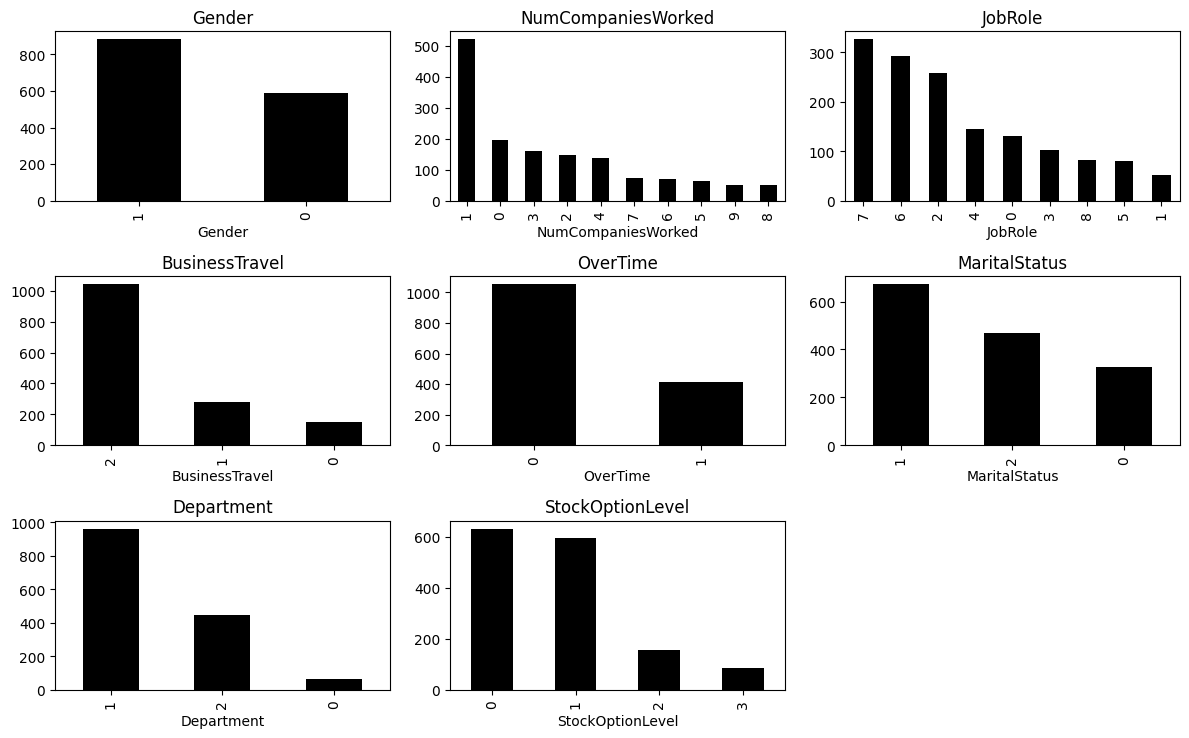

In [16]:
fig = plt.figure()

#ax = sns.heatmap(df1.iloc[:, 1:6:], annot=True, linewidths=.5)
#ax.set_title("Frequency of each sensitive features", fontsize=15) # fontweight="bold"



for groupe in range(0, len(protected_attribute_names)):
    #plt.figure(figsize = (4,2))
    protected_attribute_name = list(privileged_groups[groupe].keys())[0]
    #encoded_data[protected_attribute_name].value_counts().plot(kind='bar')
    ax = fig.add_subplot(5,3,groupe+1)

    
    vc=encoded_data[protected_attribute_name].value_counts()
    ax=vc.plot(kind='bar', figsize=(12,12), title=protected_attribute_name, color = 'black')
    #axes.plot(vc)


plt.tight_layout()
plt.show()

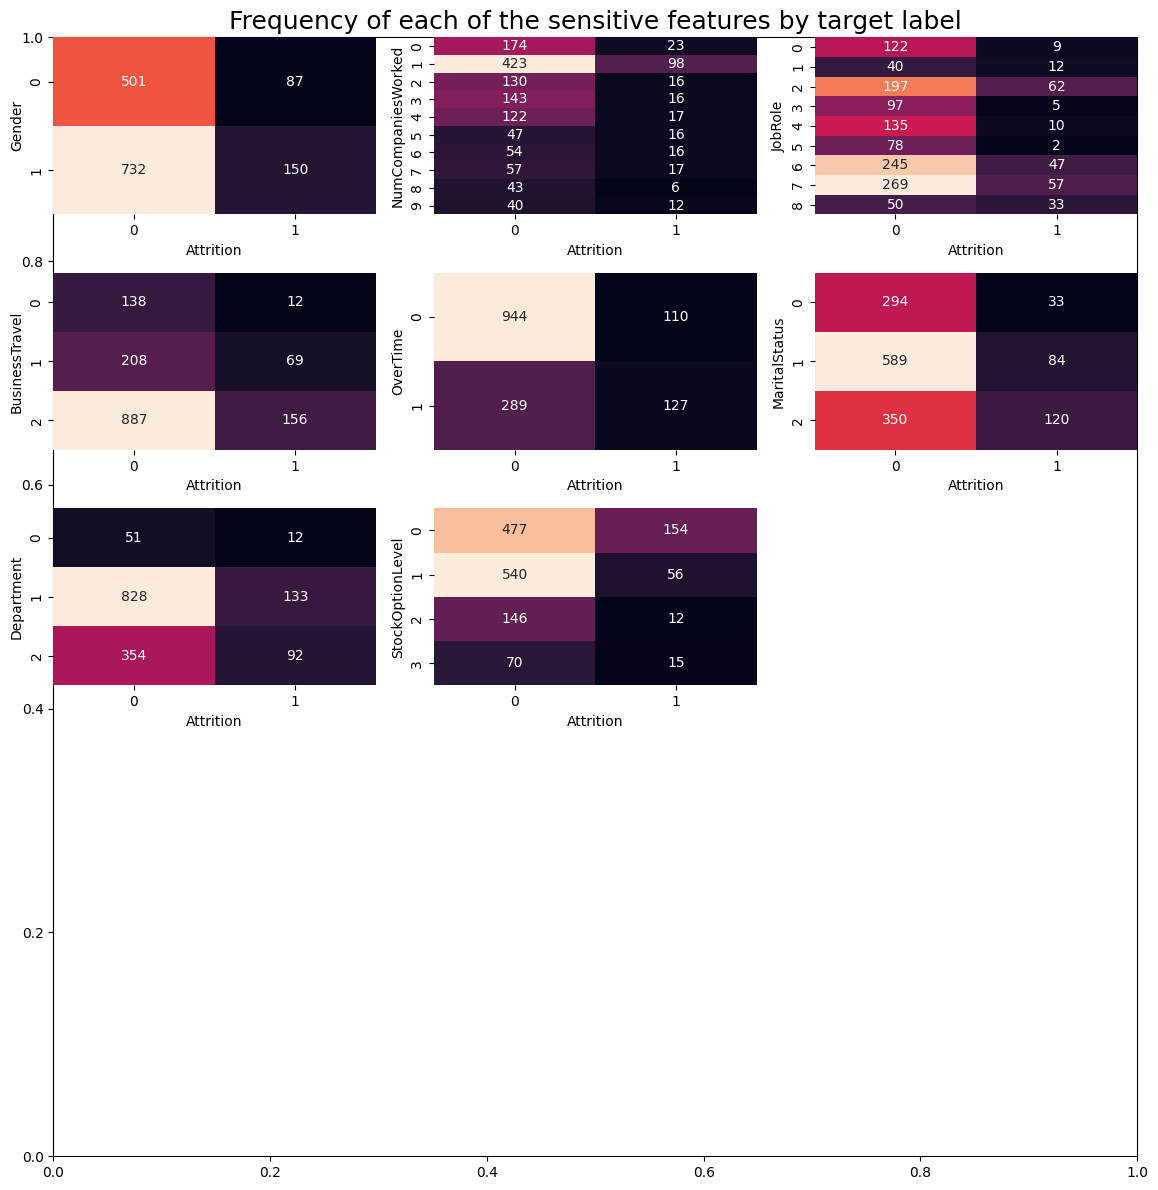

In [17]:
#fig = plt.figure()
fig, ax = plt.subplots(figsize=(12,12))
#plt.suptitle('lalala')
ax.set_title("Frequency of each of the sensitive features by target label", fontsize=18)


for groupe in range(0, len(protected_attribute_names)):
    #_,ax = plt.figure(figsize = (8,8))
    protected_attribute_name = list(privileged_groups[groupe].keys())[0]
    #encoded_data[protected_attribute_name].value_counts().plot(kind='bar')
    ax = fig.add_subplot(5,3,groupe+1)

    plotdf=pd.crosstab(encoded_data[protected_attribute_name], encoded_data['Attrition'])
    ax=sns.heatmap(plotdf, annot=True, fmt='g', cbar=False, ax=ax)    #axes.plot(vc)
    #print (type(axes))


plt.tight_layout()
plt.show()

## Removing bias from data using reweighting technique



In [18]:
def Reweighing1 (encoded_data, choice, target_feature, pval, upval, fav=0, unfav=1):


    dummy = np.repeat(1, len(encoded_data)) 
    encoded_data['dummy'] = dummy

    n = np.sum(encoded_data['dummy']) #Total number of instances
    sa = np.sum(encoded_data['dummy'][encoded_data[choice]==pval]) #Total number of privileged
    sd = np.sum(encoded_data['dummy'][encoded_data[choice]==upval]) #Total number of unprivileged
    ypos = np.sum(encoded_data['dummy'][encoded_data[target_feature]==fav]) #Total number of favourable
    yneg = np.sum(encoded_data['dummy'][encoded_data[target_feature]==unfav]) #Total number of unfavourable
    
    data_sa_ypos = encoded_data[(encoded_data[choice]==pval) & (encoded_data[target_feature]==fav)] # priviliged and favourable
    data_sa_yneg = encoded_data[(encoded_data[choice]==pval) & (encoded_data[target_feature]==unfav)] # priviliged and unfavourable
    data_sd_ypos = encoded_data[(encoded_data[choice]==upval) & (encoded_data[target_feature]==fav)] # unpriviliged and favourable
    data_sd_yneg = encoded_data[(encoded_data[choice]==upval) & (encoded_data[target_feature]==unfav)] # unpriviliged and unfavourable

    sa_ypos = np.sum(data_sa_ypos['dummy']) #Total number of privileged and favourable
    sa_yneg = np.sum(data_sa_yneg['dummy']) #Total number of privileged and unfavourable
    sd_ypos = np.sum(data_sd_ypos['dummy']) #Total number of unprivileged and favourable
    sd_yneg = np.sum(data_sd_yneg['dummy']) #Total number of unprivileged and unfavourable

    w_sa_ypos= (ypos*sa) / (n*sa_ypos) #weight for privileged and favourable
    w_sa_yneg = (yneg*sa) / (n*sa_yneg) #weight for privileged and unfavourable
    w_sd_ypos = (ypos*sd) / (n*sd_ypos) #weight for unprivileged and favourable
    w_sd_yneg = (yneg*sd) / (n*sd_yneg) #weight for unprivileged and unfavourable

    datatest=encoded_data #.copy()
    
    print (w_sa_ypos, w_sa_yneg, w_sd_ypos, w_sd_yneg)
    
    DiscriminationBefore=(sa_ypos/sa)-(sd_ypos/sd)

    
    DiscriminationAfter=(sa_ypos/sa * w_sa_ypos)-(sd_ypos/sd * w_sd_ypos)


    print (DiscriminationBefore, DiscriminationAfter)
    
    datatest['NewWeights']= np.repeat(999, len(datatest)) 
    datatest.loc[(datatest[choice]==pval) & (datatest[target_feature]==fav), 'NewWeights'] = w_sa_ypos
    datatest.loc[(datatest[choice]==pval) & (datatest[target_feature]==unfav), 'NewWeights'] = w_sa_yneg
    datatest.loc[(datatest[choice]==upval) & (datatest[target_feature]==fav), 'NewWeights'] = w_sd_ypos
    datatest.loc[(datatest[choice]==upval) & (datatest[target_feature]==unfav), 'NewWeights'] = w_sd_yneg

    return datatest['NewWeights']

In [19]:
encoded_data['OverTime']


0       1
1       0
2       1
3       1
4       0
       ..
1465    0
1466    0
1467    1
1468    0
1469    0
Name: OverTime, Length: 1470, dtype: int64

In [20]:
# data['Combined_protected_group'] = np.where((data['OverTime'] == 0) & (data['JobRole'] == 0),0, 1)

# choice = 'Combined_protected_group'
# pval = 1
# upval = 0


encoded_data['protected_group'] = np.where((encoded_data['OverTime']==0),0, 1)

choice = 'protected_group'
pval = 1
upval = 0

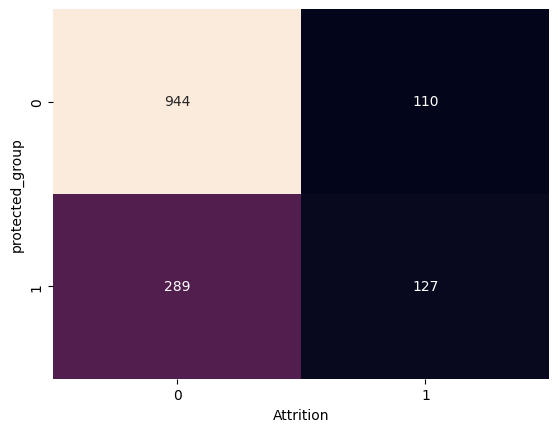

In [21]:
plotdf=pd.crosstab(encoded_data[choice], encoded_data['Attrition'])
ax=sns.heatmap(plotdf, annot=True, fmt='g', cbar=False)    #axes.plot(vc)
plt.show()

In [22]:
target_feature='Attrition'

In [23]:
dummy = np.repeat(1, len(encoded_data)) 
encoded_data['dummy'] = dummy
n = np.sum(encoded_data['dummy'])

In [24]:
sa = np.sum(encoded_data['dummy'][encoded_data[choice]==pval]) #Total number of privileged
sd = np.sum(encoded_data['dummy'][encoded_data[choice]==upval]) #Total number of unprivileged
ypos = np.sum(encoded_data['dummy'][encoded_data[target_feature]==fav]) #Total number of favourable
yneg = np.sum(encoded_data['dummy'][encoded_data[target_feature]==unfav]) #Total number of unfavourable

print("Total Advantegous: {}, Total Disdvantegous: {}, Total Favourable: {}, Total Unavourable: {}"
      .format(sa, sd, ypos, yneg))

Total Advantegous: 416, Total Disdvantegous: 1054, Total Favourable: 1233, Total Unavourable: 237


In [25]:
data = encoded_data
### we have given up replacing data to encoded_data

In [26]:
data_sa_ypos = data[(data[choice]==pval) & (data[target_feature]==fav)] # priviliged and favourable
data_sa_yneg = data[(data[choice]==pval) & (data[target_feature]==unfav)] # priviliged and unfavourable
data_sd_ypos = data[(data[choice]==upval) & (data[target_feature]==fav)] # unpriviliged and favourable
data_sd_yneg = data[(data[choice]==upval) & (data[target_feature]==unfav)] # unpriviliged and unfavourable

In [27]:
sa_ypos = np.sum(data_sa_ypos['dummy']) #Total number of privileged and favourable
sa_yneg = np.sum(data_sa_yneg['dummy']) #Total number of privileged and unfavourable
sd_ypos = np.sum(data_sd_ypos['dummy']) #Total number of unprivileged and favourable
sd_yneg = np.sum(data_sd_yneg['dummy']) #Total number of unprivileged and unfavourable

print("Total number of the Advantaged and Favourable Group: {}".format(sa_ypos))
print("Total number of Advantaged and Unfavourable Group: {}".format(sa_yneg))
print("Total number of Disadvantaged and Favourable Group: {}".format(sd_ypos))
print("Total number of Disadvantaged and Unfavourable Group: {}".format(sd_yneg))

Total number of the Advantaged and Favourable Group: 289
Total number of Advantaged and Unfavourable Group: 127
Total number of Disadvantaged and Favourable Group: 944
Total number of Disadvantaged and Unfavourable Group: 110


In [28]:
w_sa_ypos= (ypos*sa) / (n*sa_ypos) #weight for privileged and favourable
w_sa_yneg = (yneg*sa) / (n*sa_yneg) #weight for privileged and unfavourable
w_sd_ypos = (ypos*sd) / (n*sd_ypos) #weight for unprivileged and favourable
w_sd_yneg = (yneg*sd) / (n*sd_yneg) #weight for unprivileged and unfavourable

print("Weights for the Advantaged and Favourable Group: {}".format(w_sa_ypos))
print("Weights for the Advantaged and Unfavourable Group: {}".format(w_sa_yneg))
print("Weights for the Disadvantaged and Favourable Group: {}".format(w_sd_ypos))
print("Weights for the Disadvantaged and Unfavourable Group: {}".format(w_sd_yneg))

Weights for the Advantaged and Favourable Group: 1.2073723607089895
Weights for the Advantaged and Unfavourable Group: 0.5281054153945043
Weights for the Disadvantaged and Favourable Group: 0.9365141819439641
Weights for the Disadvantaged and Unfavourable Group: 1.5448237476808906


In [29]:
datatest=data #.copy()

DiscriminationBefore=(sa_ypos/sa)-(sd_ypos/sd)
DiscriminationAfter=(sa_ypos/sa * w_sa_ypos)-(sd_ypos/sd * w_sd_ypos)

print("Discrimination Before: {}, Discrimination After: {}".format(abs(DiscriminationBefore),
                                                                           abs(DiscriminationAfter)))

Discrimination Before: 0.20092413516274998, Discrimination After: 1.1102230246251565e-16


In [30]:
datatest['Weights']= np.repeat(999, len(datatest)) 
datatest.loc[(datatest[choice]==pval) & (datatest[target_feature]==fav), 'Weights'] = w_sa_ypos
datatest.loc[(datatest[choice]==pval) & (datatest[target_feature]==unfav), 'Weights'] = w_sa_yneg
datatest.loc[(datatest[choice]==upval) & (datatest[target_feature]==fav), 'Weights'] = w_sd_ypos
datatest.loc[(datatest[choice]==upval) & (datatest[target_feature]==unfav), 'Weights'] = w_sd_yneg
datatest['Weights'].head()

0    0.528105
1    0.936514
2    0.528105
3    1.207372
4    0.936514
Name: Weights, dtype: float64

## Model development with and without weights

In [31]:
target=['Attrition']

In [32]:
x=datatest.drop(columns=['Age', 'dummy','Attrition'])
y=datatest['Attrition']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30)

In [34]:
X_train_weights=X_train['Weights']
X_test_weights=X_test['Weights']

X_train1=X_train.drop(columns=["Weights",'OverTime','Over18','EmployeeCount','EmployeeNumber'])
X_test1=X_test.drop(columns=["Weights",'OverTime','Over18','EmployeeCount','EmployeeNumber'])

In [35]:
X_train1.columns

Index(['BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'protected_group'],
      dtype='object')

In [36]:
X_train1.head()

,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,protected_group
655,2,1075,0,3,2,0,4,1,57,3,...,80,1,7,4,4,4,3,0,3,1
354,0,641,2,25,2,5,4,0,85,3,...,80,1,4,2,4,2,2,2,2,1
1028,2,1283,1,5,5,3,2,1,90,4,...,80,0,7,5,2,4,2,0,3,1
257,2,1416,1,2,2,3,1,1,49,3,...,80,1,22,5,3,21,7,3,9,0
37,2,890,2,2,3,2,4,0,97,3,...,80,0,2,3,3,2,2,2,2,0


**Model without weights**

In [37]:
clf_wow = LogisticRegression(random_state=12, solver='lbfgs').fit(X_train1, y_train)

In [38]:
coefficients = clf_wow.coef_[0]
intercept = clf_wow.intercept_[0]

print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(X_train1.columns, coefficients):
    print(f"{feature}: {coef}")

Intercept: 6.073250022279912e-06
Coefficients:
BusinessTravel: 0.0005917239731856568
DailyRate: -0.0003984164319498911
Department: 0.004181861709508407
DistanceFromHome: 0.025507614279327285
Education: -0.0015891700759009645
EducationField: 0.0055697772224719685
EnvironmentSatisfaction: -0.007663561001572167
Gender: 0.0008986826972324909
HourlyRate: -0.006926646898078143
JobInvolvement: -0.007586555424877763
JobLevel: -0.010444018969111032
JobRole: 0.016447117540352357
JobSatisfaction: -0.010572359365076492
MaritalStatus: 0.009605970201007988
MonthlyIncome: 1.2373919294529573e-06
MonthlyRate: -6.296664565984478e-07
NumCompaniesWorked: 0.014511663175606163
PercentSalaryHike: -0.013613737565639477
PerformanceRating: -0.0010656848118794308
RelationshipSatisfaction: -0.005141020716370572
StandardHours: 0.00048773704339059577
StockOptionLevel: -0.01008809867007444
TotalWorkingYears: -0.05758026720149391
TrainingTimesLastYear: -0.005865124384180399
WorkLifeBalance: -0.005491854763311905
Year

In [39]:
y_pred_wow=clf_wow.predict(X_test1)
y_pred_prob_wow=clf_wow.predict_proba(X_test1)[:,0]

In [40]:
choice


'protected_group'

**Total accuracy of the model**

In [41]:
print("Accuracy of the model without weights:", clf_wow.score(X_test1, y_test))

Accuracy of the model without weights: 0.8480725623582767


**Accuracy difference between privileged and unprivileged group**

In [42]:
A_wow=clf_wow.score(X_test1[X_test1[choice]==0], y_test[X_test1[choice]==0]) #pval = 0 is Priviliged
B_wow=clf_wow.score(X_test1[X_test1[choice]==1], y_test[X_test1[choice]==1]) #pval = 1 is Unpriviliged
print("Accuracy difference between two groups:", abs(B_wow-A_wow)*100, "%")

Accuracy difference between two groups: 19.156498673740053 %


**Model with weights**

In [43]:
clf_ww = LogisticRegression(random_state=12, solver='lbfgs').fit(X_train1, y_train, sample_weight=X_train_weights)


In [44]:
y_pred_ww = clf_ww.predict(X_test1)
y_pred_prob_ww = clf_ww.predict_proba(X_test1)[:,0]

In [45]:
print("Accuracy of the model with weights:", clf_ww.score(X_test1, y_test))

Accuracy of the model with weights: 0.8480725623582767


**Accuracy difference between privileged and unprivileged group (model with weights)**

In [46]:
A_ww=clf_ww.score(X_test1[X_test1[choice]==0], y_test[X_test1[choice]==0])
B_ww=clf_ww.score(X_test1[X_test1[choice]==1], y_test[X_test1[choice]==1])
print("Accuracy difference between two groups:", abs(B_ww-A_ww)*100, "%" )

Accuracy difference between two groups: 19.156498673740053 %


### Various other accuracy metrics before and after reweighing

In [47]:
model_perf=[model_metrics(y_test, y_pred_prob_ww, y_pred_prob_wow, 
                          y_pred_ww, y_pred_wow, X_test1)]

print(model_perf)

headers=["AUC", "Gini", "Avg Precision Score", "Precision", "Sensitivity", "False Negative Rate", 
         "F1 Score"]


#full_metric={'With Weights':B, 
#             'Without_Weights':list(ww[0]), 'Without_Weights':list(wow[0])}

#compare_table=pd.DataFrame.from_dict(ww_wow)

B = list(model_perf[0])[:len(list(model_perf[0]))//2]
C = list(model_perf[0])[len(list(model_perf[0]))//2:]

print(B, C)


model_table={'Metrics':headers, 
             'With_Weights':B, 'Without_Weights':C}

model_table_df=pd.DataFrame.from_dict(model_table)
# model_table_df.loc[8] = ['Total Cost (in Mn)', model_table_df.iloc[7,1]/10000000, model_table_df.iloc[7,2]/10000000]
print(model_table_df)

374 0 67 0
374 0 67 0
################################################################################
0 0 67 0
################################################################################
[(0.33035357969510737, -0.33929284060978526, 0.15192743764172337, nan, 0.0, 1.0, 0.0, 0.3182616330114135, -0.3634767339771729, 0.15192743764172337, nan, 0.0, 1.0, 0.0)]
[0.33035357969510737, -0.33929284060978526, 0.15192743764172337, nan, 0.0, 1.0, 0.0] [0.3182616330114135, -0.3634767339771729, 0.15192743764172337, nan, 0.0, 1.0, 0.0]
               Metrics  With_Weights  Without_Weights
0                  AUC      0.330354         0.318262
1                 Gini     -0.339293        -0.363477
2  Avg Precision Score      0.151927         0.151927
3            Precision           NaN              NaN
4          Sensitivity      0.000000         0.000000
5  False Negative Rate      1.000000         1.000000
6             F1 Score      0.000000         0.000000


In [48]:
model_table_df

,Metrics,With_Weights,Without_Weights
0,AUC,0.330354,0.318262
1,Gini,-0.339293,-0.363477
2,Avg Precision Score,0.151927,0.151927
3,Precision,NaN,NaN
4,Sensitivity,0.000000,0.000000
5,False Negative Rate,1.000000,1.000000
6,F1 Score,0.000000,0.000000


In [49]:
model_table_df

,Metrics,With_Weights,Without_Weights
0,AUC,0.330354,0.318262
1,Gini,-0.339293,-0.363477
2,Avg Precision Score,0.151927,0.151927
3,Precision,NaN,NaN
4,Sensitivity,0.000000,0.000000
5,False Negative Rate,1.000000,1.000000
6,F1 Score,0.000000,0.000000


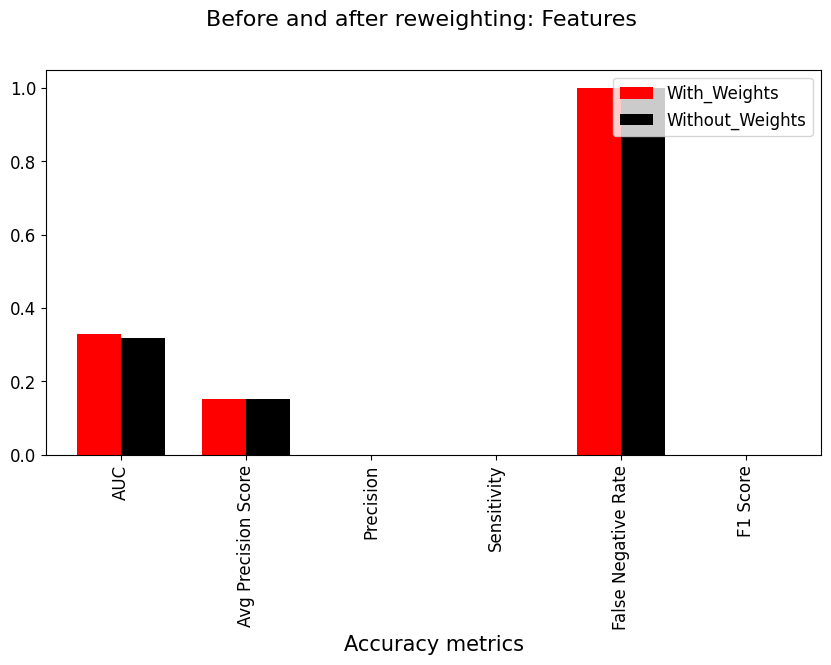

In [50]:
txt='Features'

ax = model_table_df.iloc[[0,2,3,4,5,6],:].plot.bar(x='Metrics', rot=90, width = 0.7, 
                                                       color=['red', 'black'], figsize=(10,5), fontsize=12)
plt.suptitle('Before and after reweighting: {}'.format(txt),  fontsize=16, y=1)



patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, labels, loc='upper right', fontsize=12)

ax.set_xlabel('Accuracy metrics', fontsize=15)

plt.show()

In [51]:
ww=[perf_metrics(y_test, y_pred_prob_ww, y_pred_ww, X_test1, choice, pval, upval)]
wow=[perf_metrics(y_test, y_pred_prob_wow, y_pred_wow, X_test1, choice, pval, upval)]
headers=["AUC", "Avg Precision", "Eq Oppo", "Eq Of Odds", "Precision", 
         "Demo Parity", "Avg Odds Diff", "Pred Equality", "Treatment Equality", "Pred Parity"
         ]

In [52]:
ww_wow={'Metrics':headers, 
             'With_Weights':list(ww[0]), 'Without_Weights':list(wow[0])}

compare_table=pd.DataFrame.from_dict(ww_wow)
# compare_table.loc[12] = ['Total Cost (in Mn)', compare_table.iloc[11,1]/10000000, compare_table.iloc[11,2]/10000000]

ValueError: All arrays must be of the same length

In [ ]:
compare_table

,Metrics,With_Weights,Without_Weights
0,AUC,7.926107e-03,0.002595
1,Avg Precision,1.572228e-01,0.157583
2,Eq Oppo,0.000000e+00,0.000000
3,Eq Of Odds,1.123596e-02,0.000000
4,Precision,NaN,NaN
5,Demo Parity,8.000000e-03,0.000000
6,Avg Odds Diff,-5.617978e-03,0.000000
7,Pred Equality,1.123596e-02,0.000000
8,Treatment Equality,inf,NaN
9,Pred Parity,NaN,NaN


Text(0.5, 0, 'Fairness metrics')

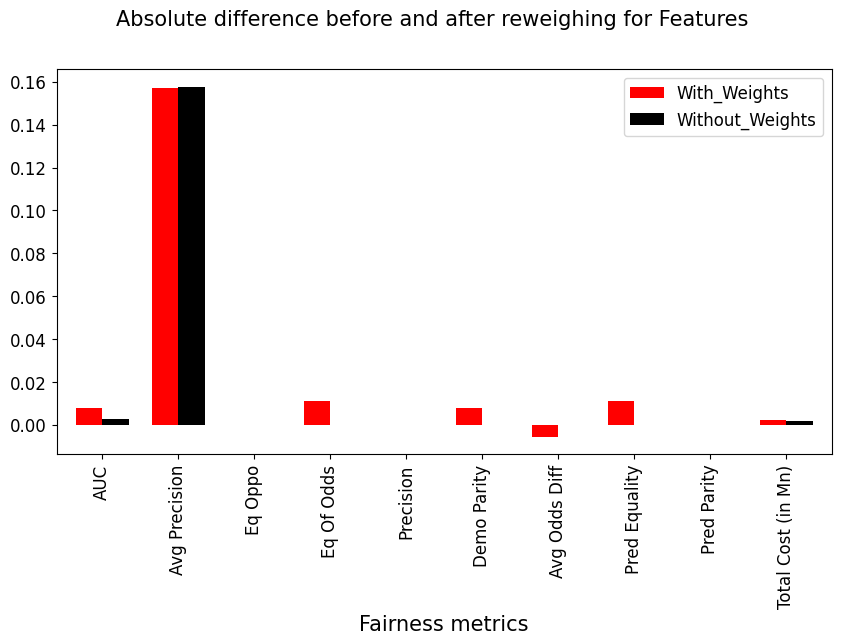

In [ ]:
ax = compare_table.iloc[[0,1,2,3,4,5,6,7,9,12],:].plot.bar(x='Metrics', rot=90, width = 0.7, color=['red', 'black'], 
                                                           figsize=(10,5), fontsize=12)
plt.suptitle('Absolute difference before and after reweighing for {}'.format(txt),  
             fontsize=15, y=1)




patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, labels, loc='upper right', fontsize=12)


ax.set_xlabel('Fairness metrics', fontsize=15)